# 06 — Failure analysis and interview capstone

*The full dataset remains outside Git. These notebooks combine synthetic worked examples, aggregate evidence, and small attributed qualitative panels.*

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

## How to use this capstone

This notebook is a compact oral-exam pass over the project. Before reading each
answer, I should explain the input, output, inductive bias, loss, selection rule,
test unit, result, limitation, and next experiment in my own words.

## The project in one diagram

```text
ZOD sequences ── causal state windows ──┬─ CV / CTRV
                                       ├─ frozen B2 MLP
                                       ├─ NeuralODE + multiple shooting
                                       ├─ hybrid physics NeuralODE
                                       └─ temporal FNO ──► 30-point trajectory

ZOD keyframes ── road/lane masks ──────┬─ DeepLabV3-MobileNet
                                       ├─ ResNet-18 U-Net
                                       └─ Fourier U-Net ──► overlapping masks

ZOD LiDAR ── calibrated BEV ────────────┬─ SFA3D oriented boxes
                                       └─ Kalman association ──► object tracks
```

## Experimental lifecycle

1. **Define:** causal tensors, coordinate frame, model families, seeds, metrics.
2. **Fit:** learn parameters on train; target-derived shooting states stay here.
3. **Select:** choose epochs and segmentation thresholds on validation.
4. **Seal:** evaluate each selected seed once on test.
5. **Infer:** compute paired differences and resample recording groups.
6. **Decide:** promote a model using accuracy, uncertainty, latency, and size.

For paired sample loss $d_i=m_A(i)-m_B(i)$, grouping by recording $g$ prevents
overlapping windows from masquerading as independent evidence. A bootstrap draw
samples recordings with replacement and includes all their windows:

\[
\hat\Delta^{*(b)}=\frac{1}{N_b}\sum_{g\in G^{*(b)}}\sum_{i:g(i)=g}d_i.
\]

The 2.5th and 97.5th percentiles of 2,000 draws form the reported 95% interval.
For ADE differences, negative favors the candidate; for segmentation score,
positive favors the candidate.

## Evidence matrix

| Question | Evidence | Defensible answer |
|---|---|---|
| Does continuous modeling help B2? | Three candidates; paired recording CIs | Yes |
| Does exact kinematic bias win? | Hybrid vs generic ODE | No |
| Does FNO preserve accuracy at lower latency? | ADE and GPU latency | Yes |
| Do U-Net skips improve thin lanes? | DeepLab vs both U-Nets | Yes |
| Does Fourier U-Net beat U-Net? | Direct paired CI and efficiency | Not established |
| Does a KITTI LiDAR detector transfer to ZOD? | Fixed 12-frame mini diagnostic | Vehicles partly; vulnerable users do not |

In [2]:
dyn_pairs = summary['dynamics']['paired_difference_candidate_minus_b2']
rows=[]
for model, metrics in dyn_pairs.items():
    ci=metrics['delta_ade_m']; rows.append([model,ci['estimate'],ci['lower'],ci['upper']])
pd.DataFrame(rows,columns=['candidate','delta_ADE','CI_low','CI_high']).round(4)

,candidate,delta_ADE,CI_low,CI_high
0,hybrid_neural_ode,-0.1226,-0.1475,-0.0971
1,neural_ode,-0.1297,-0.1550,-0.1046
2,temporal_fno,-0.1308,-0.1546,-0.1080


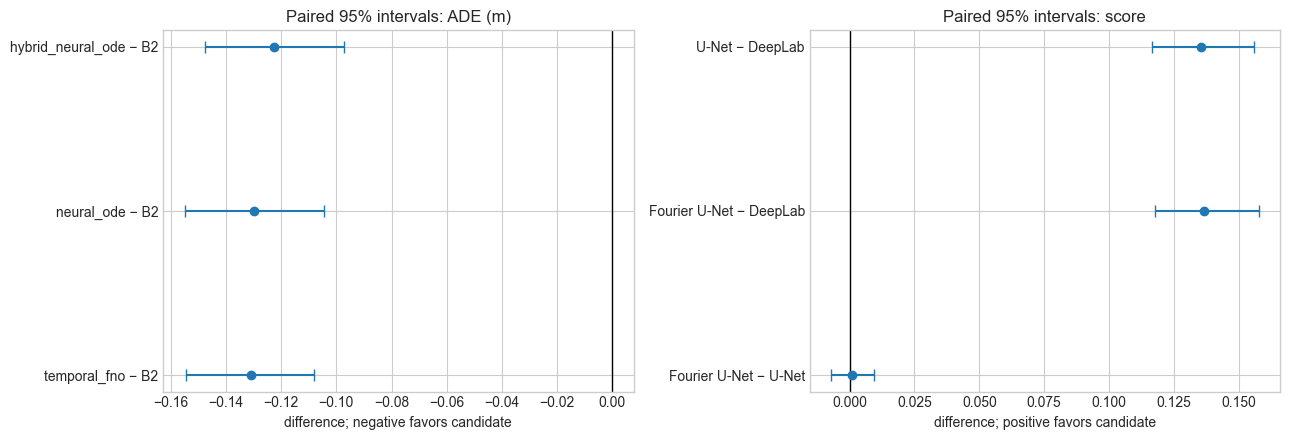

In [3]:
forest=[]
for model,metrics in dyn_pairs.items():
    ci=metrics['delta_ade_m']; forest.append((f'{model} − B2',ci['estimate'],ci['lower'],ci['upper'],'ADE (m)'))
against_deeplab = summary['segmentation']['paired_difference_candidate_minus_deeplab']
for key,label in [('resnet18_unet','U-Net − DeepLab'),
                  ('resnet18_fourier_unet','Fourier U-Net − DeepLab')]:
    ci=against_deeplab[key]['delta_selection_score']
    forest.append((label,ci['estimate'],ci['lower'],ci['upper'],'score'))
ci=summary['fourier_unet_minus_unet_per_image']['delta_selection_score']
forest.append(('Fourier U-Net − U-Net',ci['estimate'],ci['lower'],ci['upper'],'score'))
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for ax,unit,better in zip(axes,['ADE (m)','score'],['negative favors candidate','positive favors candidate']):
    subset=[x for x in forest if x[4]==unit]
    y=np.arange(len(subset)); est=np.array([x[1] for x in subset]); lo=np.array([x[2] for x in subset]); hi=np.array([x[3] for x in subset])
    ax.errorbar(est,y,xerr=[est-lo,hi-est],fmt='o',capsize=4)
    ax.axvline(0,color='black',lw=1); ax.set_yticks(y,[x[0] for x in subset]); ax.invert_yaxis()
    ax.set_xlabel(f'difference; {better}'); ax.set_title(f'Paired 95% intervals: {unit}')
plt.tight_layout(); plt.show()

## Failure modes I would inspect next

### Dynamics

- turns with biased or delayed yaw rate;
- braking transitions, where constant-command priors fail;
- long straight highway windows that dominate aggregate metrics;
- invalid or stale control channels;
- country and collection-car shifts.

### Segmentation

- worn or occluded lane markings;
- road boundaries under snow, glare, or construction;
- predictions that exploit a thick tolerance band;
- country-specific markings absent from the small test role;
- threshold drift under camera exposure changes.

For each slice I would report support, the same frozen metric, a paired model
difference where possible, and representative *private* examples outside Git.
Slicing after seeing test results is exploratory diagnosis, not a new confirmatory
claim; a subsequent test role would be needed to confirm a discovered subgroup.

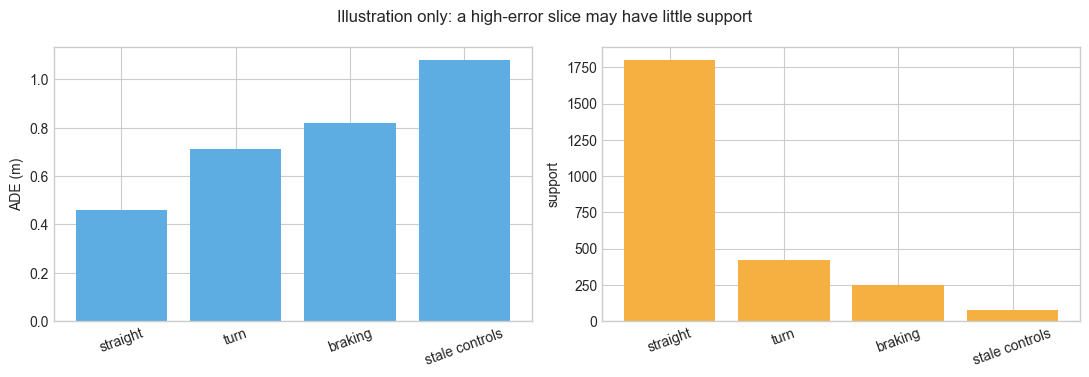

In [4]:
# Synthetic example of why aggregate metrics need slice support.
slices=pd.DataFrame({
    'slice':['straight','turn','braking','stale controls'],
    'windows':[1800,420,250,79],
    'ADE_m':[.46,.71,.82,1.08],
})
fig,ax=plt.subplots(1,2,figsize=(11,3.8))
ax[0].bar(slices['slice'],slices['ADE_m'],color='#5dade2'); ax[0].tick_params(axis='x',rotation=20); ax[0].set_ylabel('ADE (m)')
ax[1].bar(slices['slice'],slices['windows'],color='#f5b041'); ax[1].tick_params(axis='x',rotation=20); ax[1].set_ylabel('support')
fig.suptitle('Illustration only: a high-error slice may have little support'); plt.tight_layout(); plt.show()

## Architecture and loss flash cards

| Model | Inductive bias | Objective | Main limitation |
|---|---|---|---|
| B2 MLP | finite vector mapping | trajectory ADE | no explicit temporal operator/physics |
| NeuralODE | continuous second-order field | shooting + continuity + full ADE | sequential solver latency |
| Hybrid ODE | exact kinematic core | same multiple-shooting loss | biased physics/control assumptions |
| Temporal FNO | global low-mode temporal mixing + CTRV residual | full ADE | fixed-grid spectral design |
| DeepLab | atrous semantic context | weighted multilabel BCE | weaker thin-detail recovery here |
| U-Net | multiscale encoder skips | weighted multilabel BCE | larger than DeepLab reference |
| Fourier U-Net | U-Net + global spectral bottleneck | same BCE | 4× parameters, no reliable score gain |
| SFA3D | BEV center heatmaps + box heads | external focal + regression losses | KITTI→ZOD class/domain shift |
| Kalman tracker | constant-velocity Gaussian state | recursive filtering, no learned loss | simple nearest-neighbor association |

Promotion is not determined by training loss. The chosen checkpoint is judged by
validation, then its final claim uses sealed test metrics and grouped uncertainty.

## Interview drill

Pause before expanding each answer.

1. **Why is target-derived multiple shooting not test leakage?**  
   It is training-only intermediate supervision. `forward()` never accepts a
   boundary target, and evaluation performs one causal rollout.

2. **Why bootstrap recordings?**  
   Overlapping windows from one recording are correlated. Window bootstrap
   would pretend the effective sample size is much larger than it is.

3. **Why report both strict lane IoU and tolerant F1?**  
   Tolerance reflects geometric usefulness for thin lines; strict IoU prevents
   a thick imprecise mask from looking perfect.

4. **Why not claim Fourier U-Net wins?**  
   Its paired interval crosses zero and its compute cost is much higher.

5. **What is the cleanest next experiment?**  
   Train a ZOD-native BEV detector with a protected split, then test whether
   camera–LiDAR fusion repairs the vulnerable-road-user transfer gap.

6. **Why is temporal FNO called best if its NeuralODE gap is tiny?**  
   It is the best measured and promoted engineering point: essentially tied
   accuracy with much lower latency. I do not claim statistically proven FNO
   accuracy superiority over NeuralODE.

7. **Did Fourier U-Net improve the original project?**  
   The U-Net family clearly improved the retrained DeepLab reference on a fresh
   test role. Fourier U-Net has the highest raw score, but its direct advantage
   over ordinary U-Net is uncertain and computationally expensive.

8. **Is the BEV animation evidence of a good pedestrian detector?**
   No. The fixed transfer diagnostic has zero pedestrian and cyclist true
   positives. It demonstrates calibrated geometry, decoding, and temporal
   state estimation—not a safety or multi-object-tracking claim.

In [5]:
# A compact promotion scorecard generated from frozen evidence.
scorecard = pd.DataFrame([
    ["Temporal FNO", True, True, "promote"],
    ["NeuralODE", True, False, "retain as continuous-time study"],
    ["Hybrid NeuralODE", True, False, "retain as physics study"],
    ["ResNet-18 U-Net", True, True, "promote"],
    ["Fourier U-Net", False, False, "retain as complexity control"],
    ["SFA3D KITTI→ZOD", False, True, "retain as transfer baseline"],
], columns=["model","reliable_gain","efficient_frontier","decision"])
scorecard

,model,reliable_gain,efficient_frontier,decision
0,Temporal FNO,True,True,promote
1,NeuralODE,True,False,retain as continuous-time study
2,Hybrid NeuralODE,True,False,retain as physics study
3,ResNet-18 U-Net,True,True,promote
4,Fourier U-Net,False,False,retain as complexity control
5,SFA3D KITTI→ZOD,False,True,retain as transfer baseline


## Visual recall: architecture to output

These panels are the fastest way to rehearse the project aloud: name the input
tensor, explain the model's inductive bias, point to its physical output, then
connect the visible behavior back to the sealed quantitative result.

![Model architecture overview](../reports/figures/model_architecture_overview.png)

![Camera-projected trajectory outputs](../reports/figures/dynamics_camera_predictions.png)

![Segmentation outputs](../reports/figures/segmentation_model_comparison.png)

![LiDAR BEV detection](../reports/figures/bev_detection_mini.png)

In [6]:
# Data-safe repository completeness check used during a review.
required=[
    'README.md','docs/methods.md','docs/data_and_evaluation.md','docs/interview_guide.md',
    'reports/v4_dynamics_test.json','reports/v4_segmentation_test.json',
    'reports/bev_detection_mini.json',
    'src/zod_driveformer/dynamics/models.py','src/zod_driveformer/segmentation/models.py',
    'src/zod_driveformer/bev/representation.py','src/zod_driveformer/bev/tracking.py',
]
pd.DataFrame([(name,(ROOT/name).exists()) for name in required],columns=['artifact','present'])

,artifact,present
0,README.md,True
1,docs/methods.md,True
2,docs/data_and_evaluation.md,True
3,docs/interview_guide.md,True
4,reports/v4_dynamics_test.json,True
5,reports/v4_segmentation_test.json,True
6,reports/bev_detection_mini.json,True
7,src/zod_driveformer/dynamics/models.py,True
8,src/zod_driveformer/segmentation/models.py,True
9,src/zod_driveformer/bev/representation.py,True


## Final perspective

The most valuable result is not a particular architecture. It is a disciplined
way to turn exploratory modeling into claims that survive scrutiny: protect the
test role, preserve pairing, make leakage boundaries executable, report costs,
and allow a sophisticated model to lose when its gain is not reliable.

The concise project story is: **continuous and spectral dynamics reliably beat
the strong state MLP; temporal FNO is the best accuracy–latency choice; U-Net
skips reliably repair thin-lane segmentation; extra Fourier capacity in the
U-Net bottleneck does not justify its cost; calibrated LiDAR BEV provides a
working vehicle-transfer baseline while exposing a serious vulnerable-road-user
domain gap.**